In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re
import json
from functions import *
import pandas as pd

def get_currents(file):
    def read_currents_file(filepath):
        # Read the file content
        with open(filepath, 'r') as file:
            # Read the first line to get current names
            header_line = file.readline().strip()
            
            # Split the header first by semicolons, then by commas
            current_groups = header_line.split(';')
            current_names = []
            for group in current_groups:
                currents = [name.strip() for name in group.split(',')]
                current_names.extend(currents)
                
            # Initialize dictionary with empty lists for each current
            data_dict = {name: [] for name in current_names}
            
            # Read the rest of the lines
            for line in file:
                # if start with undefined,skip
                if line.startswith("undefined"):
                    continue
                if not line.strip():  # Skip empty lines
                    continue
                
                # Split values by semicolon first, then comma
                value_groups = line.strip().split(';')
                values = []
                for group in value_groups:
                    group_values = [float(val.strip()) for val in group.split(',') if val.strip()]
                    values.extend(group_values)
                
                # Add each value to corresponding current's list
                for name, value in zip(current_names, values):
                    data_dict[name].append(value)
        
        # Convert lists to numpy arrays for easier manipulation
        for name in data_dict:
            data_dict[name] = np.array(data_dict[name])
        
        return data_dict

    # Example usage:
    filepath = file
    currents_data = read_currents_file(filepath)
    return currents_data

In [7]:
def readFile(file,unidentifiable_space = [3,5,6,7,8,9,10,11]):
    currents_data = get_currents(file)
    mask =  -100< currents_data['voltage']
    if 'NA' in currents_data:
        del currents_data['NA']
    matrix = np.zeros((len(currents_data['voltage'][mask]),len(currents_data)-1))  # Exclude voltage
    # assign currents to matrix columns
    for i, (current_name, values) in enumerate(currents_data.items()):
        if current_name not in ['voltage']:
            matrix[:, i - (1 if 'voltage' in currents_data else 0)] = values[mask]
    U, S, V = np.linalg.svd(matrix)
    def projection_S(v):
        ps = [0] * len(S)
        for i in unidentifiable_space:
            ps += np.inner(v,V[i]) / np.inner(V[i],V[i]) * V[i]
        return ps
    identifiability = {}
    for i, (current_name, values) in enumerate(currents_data.items()):
        if current_name in ['voltage']:
            continue
        v_I = [0]*len(S)
        v_I[i-1] = 1
        k = np.linalg.norm(v_I-projection_S(v_I))
        identifiability[current_name] = k
    sorted_identifiability = dict(sorted(identifiability.items(), key=lambda item: item[1], reverse=True))
    return U,S,V,currents_data,sorted_identifiability
def plot_sorted_currents_with_identifiability(currents_data, sorted_identifiability):
    # Get currents in sorted order (already sorted by identifiability)
    currents_to_plot = list(sorted_identifiability.keys())
    n_currents = len(currents_to_plot)
    
    # Create figure with special grid
    fig = plt.figure(figsize=(15, 4*(n_currents//3 + 2)))  # +2 for voltage row
    
    # Create grid with different row heights
    gs = plt.GridSpec(n_currents//3 + 2, 3, height_ratios=[1.5] + [1]*(n_currents//3 + 1))
    
    # Plot voltage across entire first row
    ax_voltage = fig.add_subplot(gs[0, :])
    ax_voltage.plot(currents_data['voltage'], 'b-')
    ax_voltage.set_title('Voltage')
    ax_voltage.set_ylabel('mV')
    ax_voltage.set_xlabel('Time Step')
    ax_voltage.grid(True)
    
    # Plot currents in remaining grid
    for idx, current_name in enumerate(currents_to_plot):
        row = (idx // 3) + 1  # +1 because voltage took first row
        col = idx % 3
        ax = fig.add_subplot(gs[row, col])
        
        # Plot the current
        ax.plot(currents_data[current_name], 'b-')
        
        # Set title with identifiability value
        identifiability_value = sorted_identifiability[current_name]
        def format_current_name(name):
            # Dictionary for special current name formatting
            current_formats = {
                'INa': 'I_{Na}',
                'ICaL': 'I_{CaL}',
                'Ito': 'I_{to}',
                'IKr': 'I_{Kr}',
                'IKs': 'I_{Ks}',
                'IK1': 'I_{K1}',
                'INaCa': 'I_{NaCa}',
                'INaK': 'I_{NaK}',
                'INab': 'I_{Nab}',
                'ICab': 'I_{Cab}',
                'IKb': 'I_{Kb}',
                'IpCa': 'I_{pCa}',
                'INalate': 'I_{Na,late}'
            }
            return current_formats.get(name, name)  # Return formatted name or original if not in dictionary

        # Then modify the title setting line to:
        ax.set_title(f'${format_current_name(current_name)}$\nIdentifiability: {identifiability_value:.3f}',fontsize=20)        
        ax.set_ylabel('Current (pA/pF)')
        ax.set_xlabel('Time Step')
        ax.grid(True)
    
    #plt.tight_layout()
    #plt.savefig('currents_sorted_by_identifiability.png', dpi=300)
    #plt.show()
    plt.close()
pacing_period = 300
file = f'voltage_TNNP_pacingPeriod{pacing_period}_APD_step_4.csv'
U,S,V,currents_data, sorted_identifiability = readFile(file)
#print(S,'S',V,sorted_identifiability)
plot_sorted_currents_with_identifiability(currents_data, sorted_identifiability)


In [10]:
######################## generate the perturbed currents json file for simulation
json_file_name = f'perturbed_currents_pacingperiod_{pacing_period}.js'
json_file = f'./2D-TNNP-sensitivity-test/{json_file_name}'

epsilon_lst = [-0.5,-0.2,0.,0.2,0.5]
# now we perturb current by singular vector with magnitude epsilon
# the order of current should be from dict current_data keys except voltage
# now we store each singular vector's perturbation into a list as well
perturbed_currents = {}
for idx,singular_vector in enumerate(V):
    perturbed_currents[idx] = {}
    for epsilon in epsilon_lst:
        perturbed_currents[idx][epsilon] =[ 1.+ epsilon *  v for v in singular_vector]
perturbed_currents_name = ['C_Na', 'C_to', 'C_CaL', 'C_Ks', 'C_pK', 'C_NaK', 'C_Kr', 'C_NaCa', 'C_K1', 'C_bCa', 'C_pCa', 'C_bNa']
# now output the dict to a js file
with open(json_file, 'w') as f:
    # 1. Write the names array
    
    f.write(f"const pacePeriod = {pacing_period};\n")
    f.write(f"const perturbed_currents_name = {json.dumps(perturbed_currents_name)};\n")
    
    # 2. Write the dictionary (the data)
    # indent=4 makes it readable; without it, it stays on one line
    f.write(f"const perturbed_currents = {json.dumps(perturbed_currents, indent=4)};")



########################## modify the simulation index file
simulation_index_file = './2D-TNNP-sensitivity-test/index.html'
indicator = "<script src='Abubu/libs/Abubu.js'></script>"
target_pattern = r'<script src=".*?"></script>'

# 3. Read the HTML file
with open(simulation_index_file, 'r') as file:
    content = file.read()

# 4. Split the content into two parts: before the indicator and after it
if indicator in content:
    parts = content.split(indicator, 1) # Split only once
    header = parts[0] + indicator
    rest_of_file = parts[1]
    
    # 5. Replace only the FIRST occurrence of a script tag in the remaining text
    new_script_tag = f'<script src="{json_file_name}"></script>'
    updated_rest = re.sub(target_pattern, new_script_tag, rest_of_file, count=1)
    
    # 6. Reconstruct the full HTML
    final_html = header + updated_rest

    # 7. Write it back to the file
    with open(simulation_index_file, 'w') as file:
        file.write(final_html)
    
    print(f"Successfully updated the line following {indicator}")
else:
    print("Indicator line not found. No changes made.")

Successfully updated the line following <script src='Abubu/libs/Abubu.js'></script>


In [44]:
# start localhost:8000 at simulation location
import webbrowser, os, time

# Set your path
simulation_folder = r'./2D-TNNP-sensitivity-test'

# 1. Change directory
#os.chdir(simulation_folder)

# 2. Open Chrome (default browser)
webbrowser.open("http://localhost:8005")

# 3. Start the server (this will stay "Running" until you stop the cell)
!python -m http.server 8005


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\xan37\AppData\Local\anaconda3\envs\ovvr_paper\Lib\http\server.py", line 1323, in <module>
    test(
    ~~~~^
        HandlerClass=handler_class,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
        protocol=args.protocol,
        ^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "c:\Users\xan37\AppData\Local\anaconda3\envs\ovvr_paper\Lib\http\server.py", line 1270, in test
    with ServerClass(addr, HandlerClass) as httpd:
         ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\xan37\AppData\Local\anaconda3\envs\ovvr_paper\Lib\socketserver.py", line 457, in __init__
    self.server_bind()
    ~~~~~~~~~~~~~~~~^^
  File "c:\Users\xan37\AppData\Local\anaconda3\envs\ovvr_paper\Lib\http\server.py", line 1317, in server_bind
    return super().server_bind()
           ~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\xan37\AppData\Local\anac

In [2]:
import csv
def get_voltage(vec,epsilon,pacing_period):
    path = f"./data/voltage_vector{vec}_epsilon_{epsilon}_pacingPeriod_{pacing_period}.csv"
    voltage = np.array([])
    with open(path) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=';')
        for row in csv_reader:
            voltage = np.append(voltage, float(row[1]))
    return voltage

In [8]:
#calculate unidentifiable space
dt = 0.2
def dvdt_max(voltage):
    return np.max(np.gradient(voltage)) / dt
def euclidian_norm(v):
    return np.linalg.norm(v)

def H_test(v_star,v_bar):
    H1 = abs(get_APD_from_voltage(v_star,0.7,dt)[0] - get_APD_from_voltage(v_bar,0.7,dt)[0]) / abs(get_APD_from_voltage(v_star,0.7,dt)[0])
    H2 = abs(get_APD_from_voltage(v_star,0.5,dt)[0] - get_APD_from_voltage(v_bar,0.5,dt)[0]) / abs(get_APD_from_voltage(v_star,0.5,dt)[0])       
    H3 = abs(get_APD_from_voltage(v_star,0.2,dt)[0] - get_APD_from_voltage(v_bar,0.2,dt)[0]) / abs(get_APD_from_voltage(v_star,0.2,dt)[0])
    H4 = abs(dvdt_max(v_star) - dvdt_max(v_bar)) / abs(dvdt_max(v_star))
    H5 = np.linalg.norm(v_star - v_bar) / np.linalg.norm(v_star)
    return H1 + H2 + H3 + H4 + H5
    
def calculate_unidentifiable_space(pacing_period):
    voltage_file = f'voltage_TNNP_pacingPeriod{pacing_period}_APD_step_4.csv'
    vec_lst = list(range(12))
    epsilon_list = [-0.5,-0.2,0.2,0.5,0.0]
    
    currents_data = get_currents(voltage_file)
    voltage = currents_data['voltage']
    Delta = 0.25
    output = list(range(12))
    for vec in vec_lst:
        for epsilon in epsilon_list:

            perturbed_voltage_file = f'voltage_vector{vec}_epsilon_{epsilon}_pacingPeriod_{pacing_period}.csv'
            
            v_star = get_currents(voltage_file)['voltage']
            v_bar = get_voltage(vec,epsilon,pacing_period)
            H_value = H_test(v_star,v_bar[1:])
            if H_value > Delta:
                # remove vec from output
                output.remove(vec)
                break
    return output

In [5]:
unidentifiable_space_dict = {}
for pacing_period in [300,500]:
    unidentifiable_space = calculate_unidentifiable_space(pacing_period)
    unidentifiable_space_dict[pacing_period] = unidentifiable_space
    

In [9]:
################### now calculate identifiability
identifiability_dict = {}
for pacing_period in [300,500]:
    file = f'voltage_TNNP_pacingPeriod{pacing_period}_APD_step_4.csv'
    U,S,V,currents_data, sorted_identifiability = readFile(file)
    #print(S,'S',V,sorted_identifiability)
    plot_sorted_currents_with_identifiability(currents_data, sorted_identifiability)
    identifiability_dict[pacing_period] = sorted_identifiability


KeyError: 1000

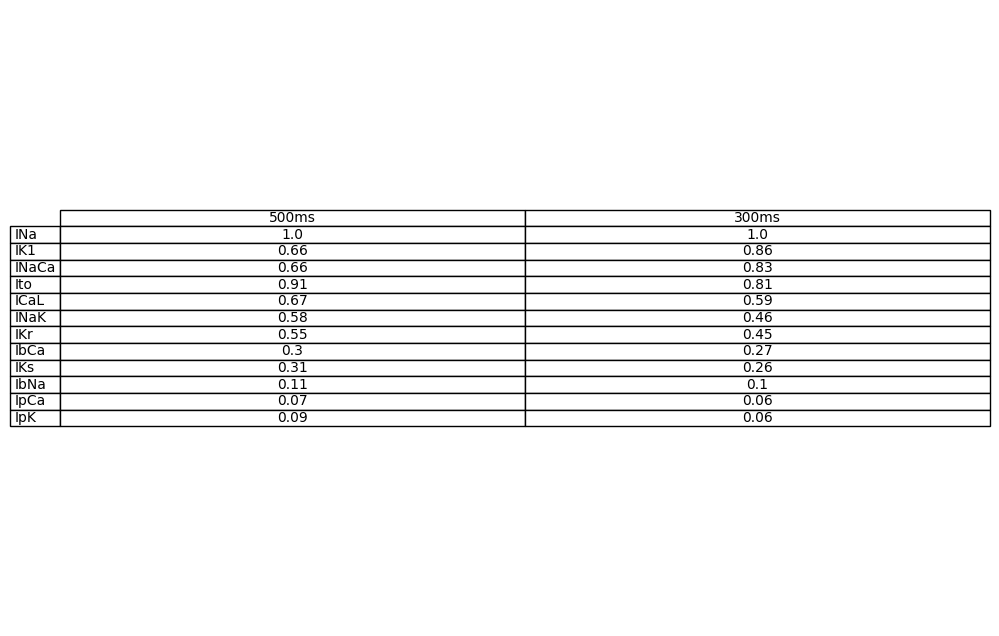

In [10]:
import matplotlib.patches as mpatches
# 1. Create and Sort the DataFrame FIRST
df = pd.DataFrame(identifiability_dict)
# Sort rows (axis=0) or columns (axis=1) as needed
df = df.sort_index(axis=1, ascending=False) 

# 2. Create the rounded version FROM the sorted version

df_rounded = df.round(2)

# 3. Create the Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('tight')
ax.axis('off')
hz_labels = [f"{c}ms" for c in df_rounded.columns]
# Use df_rounded for EVERYTHING in the table creation
table = ax.table(
    cellText=df_rounded.values,
    colLabels=hz_labels,
    rowLabels=df_rounded.index,
    cellLoc='center',
    loc='center'
)

baseline_col = 1000

# 4. Loop using the same DataFrame used for the table
for row_idx, row_label in enumerate(df_rounded.index):
    baseline_val = df_rounded.loc[row_label, baseline_col]
    
    for col_idx, col_name in enumerate(df_rounded.columns):
        # Access cell (row_idx + 1 because of header)
        cell = table[row_idx + 1, col_idx]
        
        # Explicitly set baseline column to white
        if col_name == baseline_col:
            cell.set_facecolor("white")
            continue
            
        current_val = df_rounded.loc[row_label, col_name]
        
        # Comparison Logic
        if abs(current_val - baseline_val) < 0.001:
            cell.set_facecolor("white") 
        elif current_val > baseline_val:
            cell.set_facecolor('#f8d7da') # Light Green
        elif current_val < baseline_val:
            cell.set_facecolor('#d4edda') # Light Red
            
green_patch = mpatches.Patch(color='#d4edda', label=f'Decrease vs {baseline_col}')
red_patch = mpatches.Patch(color='#f8d7da', label=f'Increase vs {baseline_col}')
white_patch = mpatches.Patch(edgecolor='black', facecolor='white', label='No change')


plt.legend(
    handles=[red_patch, green_patch, white_patch],
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.03), # Positions legend below the table
    ncol=3, 
    fontsize=10,
)
# Styling
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 2.5)
# Add a title
plt.title('Parameter Identifiability Comparison', 
          fontsize=16, 
          pad=30,          # Increases distance between title and table
          weight='bold',   # Makes the title bold
          color='#333333') # Dark grey color for a professional look
plt.savefig('identifiability_comparison_table.png', dpi=300, bbox_inches='tight')
plt.show()
